<a href="https://colab.research.google.com/github/ludwigwittgenstein2/Tamil/blob/master/_notebooks/2022_03_21_Research_Tamil_PDF_Extract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing - Extracting Text from PDF 
> A tutorial on extracting text in Jupyter notebooks

- toc: true 
- badges: true
- comments: true
- categories: [jupyter]
- image: images/chart-preview.png

## How to extract? 

In [1]:
!pip install PyMuPDF
!pip install pillow
!pip install pymupdf-fonts 
!apt-get install poppler-utils
!pip install pdf2image
!pip install easyocr

     |████████████████████████████████| 8.8 MB 30.8 MB/s 
     |████████████████████████████████| 4.2 MB 28.9 MB/s 
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 39 not upgraded.
Need to get 154 kB of archives.
After this operation, 613 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic-updates/main amd64 poppler-utils amd64 0.62.0-2ubuntu2.12 [154 kB]
Fetched 154 kB in 0s (2,008 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 155335 files and directories currently installed.)
Preparing to unpack .../poppler-utils_0.62.0-2ubuntu2.12_amd64.deb ...
Unpacking poppler-utils (0.62.0-2ubuntu2.12) ...
Setting up poppler-utils (0.62.0-2ubuntu2.12) ...
Processing triggers for man-db (2.8.3-2ubuntu0.1) ...
     |████████████████████████████████| 63.6 MB 45 kB/s 
     |

In [5]:
from pdf2image import convert_from_path
import easyocr

import numpy as np
import PIL
from PIL import ImageDraw
import spacy

In [23]:
!pip install import TesseractOCR

ERROR: Could not find a version that satisfies the requirement import (from versions: none)
ERROR: No matching distribution found for import


In [3]:
!pip uninstall opencv-python-headless==4.5.5.62

Found existing installation: opencv-python-headless 4.5.5.64
Uninstalling opencv-python-headless-4.5.5.64:
  Would remove:
    /usr/local/lib/python3.7/dist-packages/cv2/*
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless-4.5.5.64.dist-info/*
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libavcodec-65fa80df.so.58.134.100
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libavformat-8ef5c7db.so.58.76.100
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libavutil-9c768859.so.56.70.100
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libbz2-a273e504.so.1.0.6
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libcrypto-09fe7800.so.1.1
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libgfortran-91cc3cb1.so.3.0.0
    /usr/local/lib/python3.7/dist-packages/opencv_python_headless.libs/libopenblas-r0-f650aae0.3.3.so
    /usr/local/lib/python3.7/dis

In [4]:
!pip install opencv-python-headless==4.1.2.30

     |████████████████████████████████| 21.8 MB 12.1 MB/s 


In [26]:
reader=easyocr.Reader(['ta'])

CUDA not available - defaulting to CPU. Note: This module is much faster with a GPU.


In [27]:
images = convert_from_path('attention.pdf')

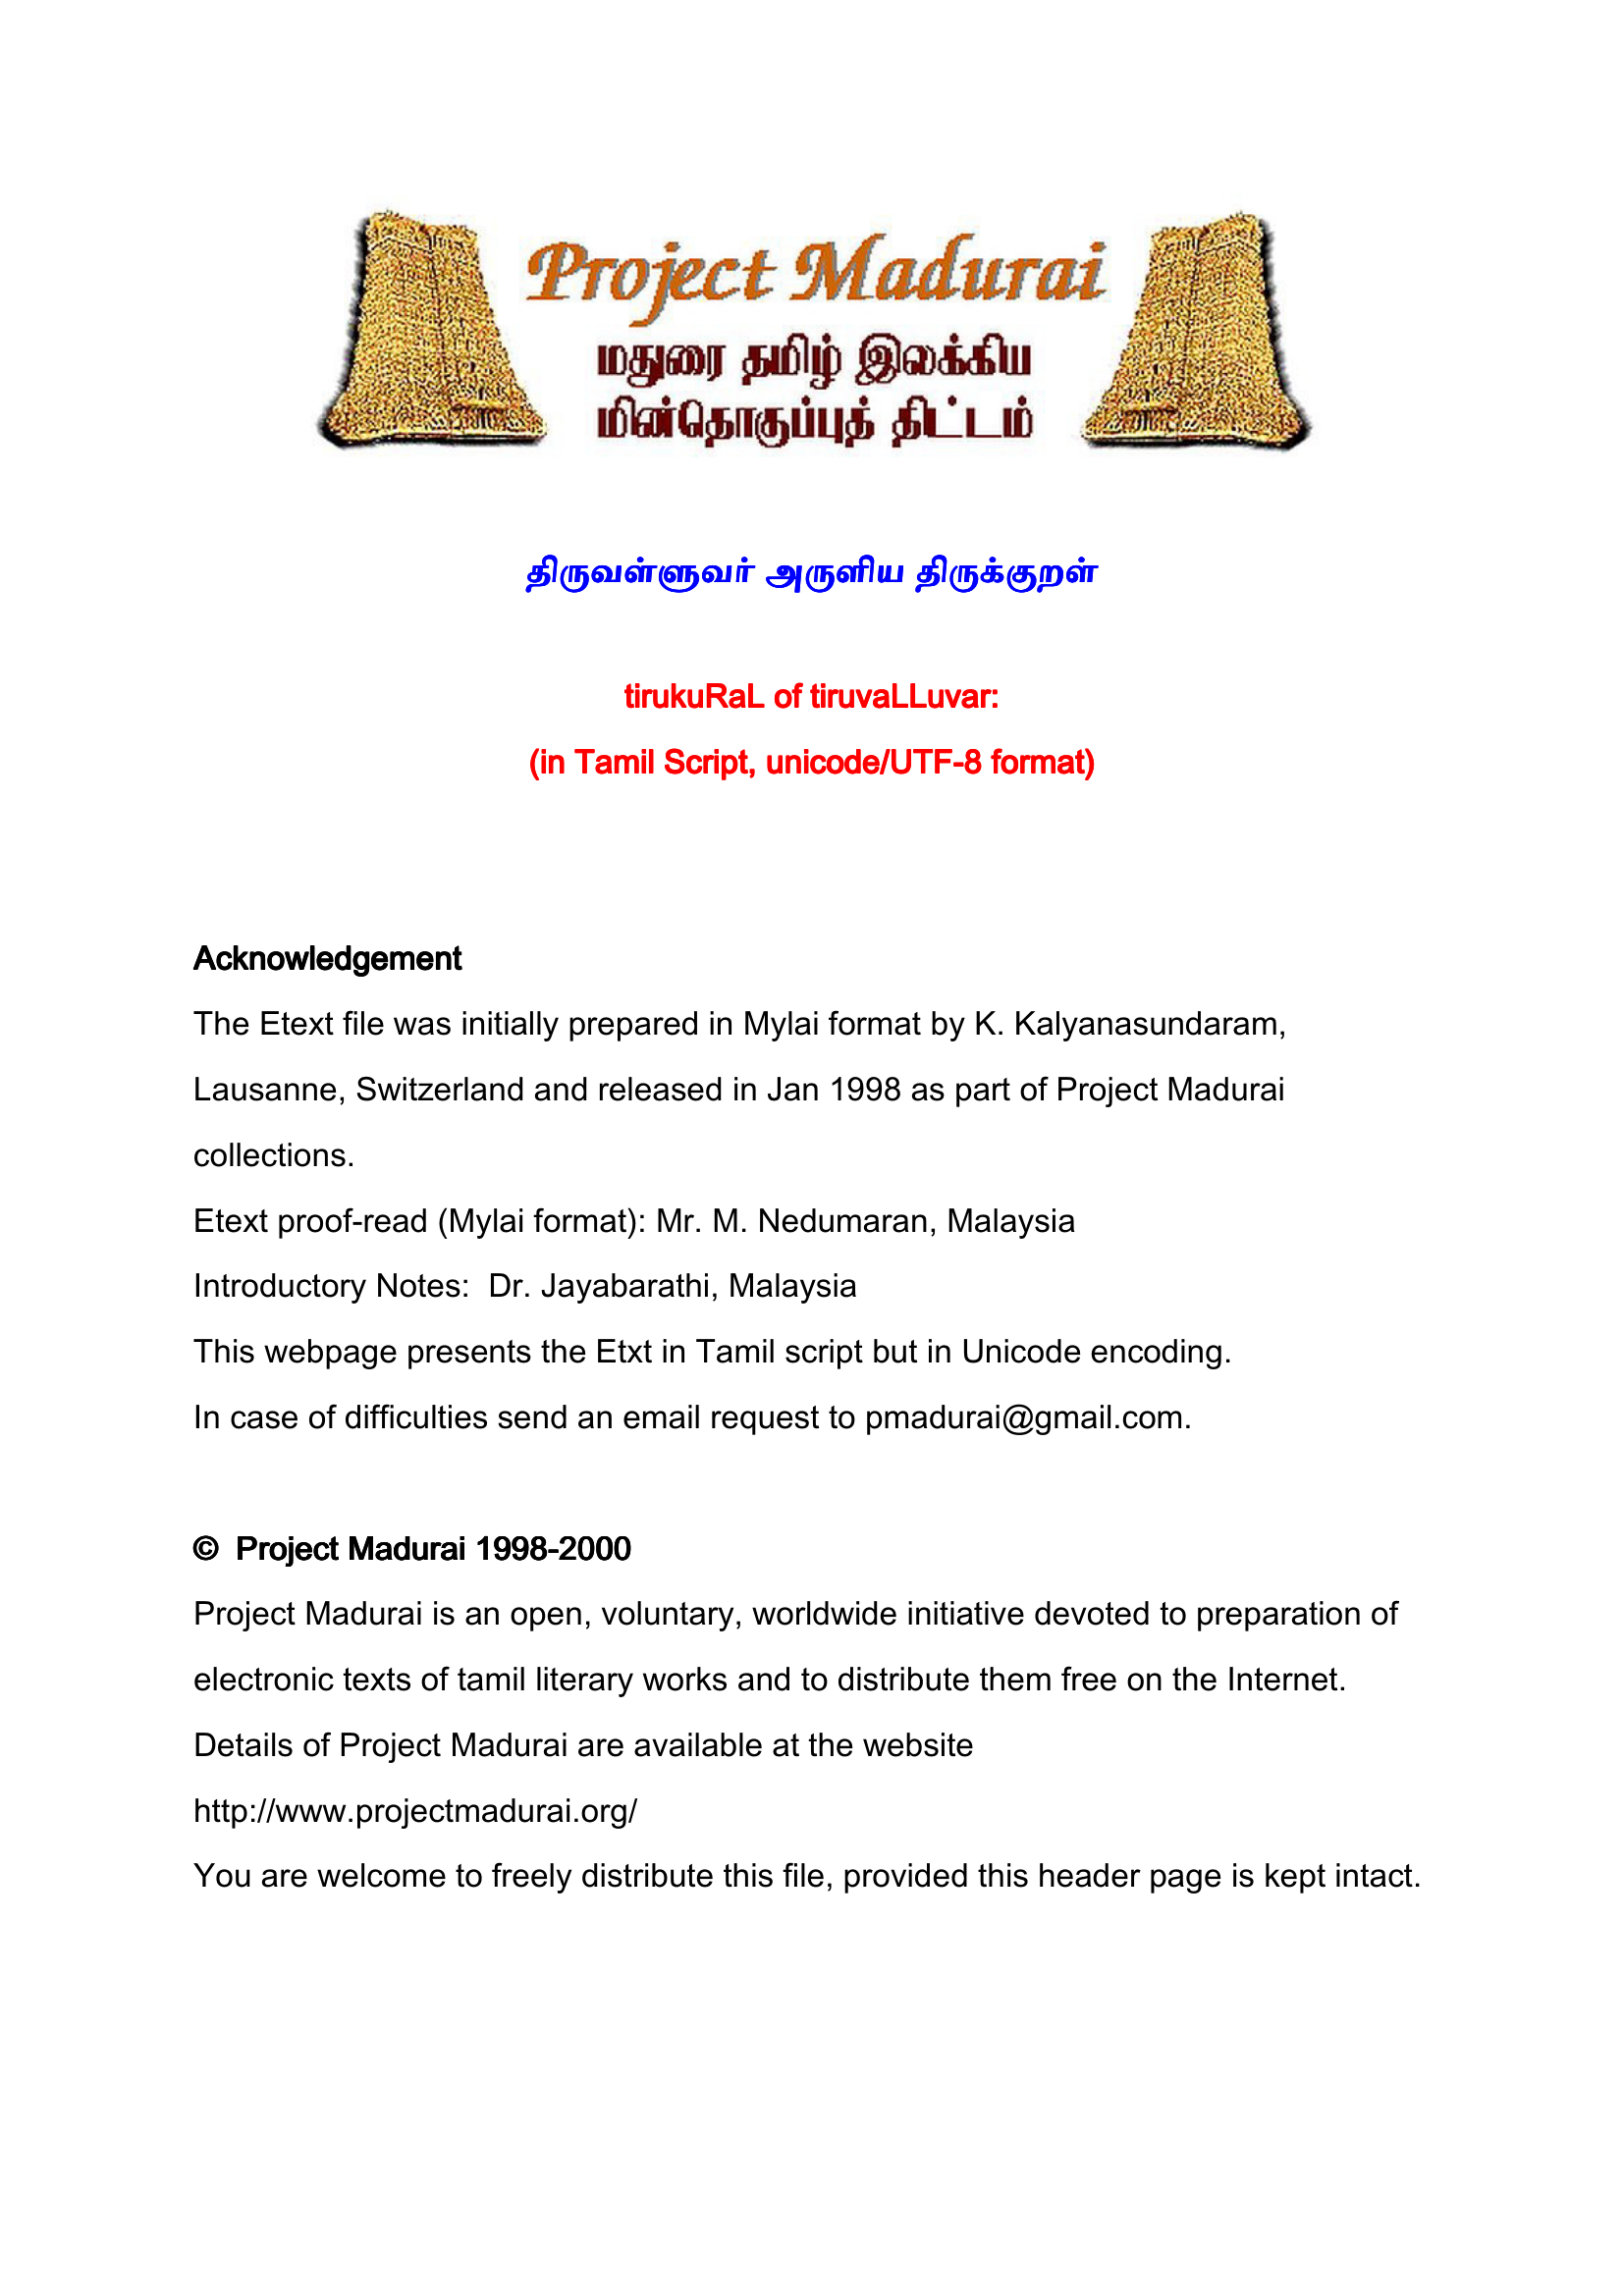

In [29]:
from IPython.display import display, Image 
display(images[0])

In [30]:
bounds = reader.readtext(np.array(images[0]),min_size=0, slope_ths=0.2, ycenter_ths=0.7, height_ths=0.6, width_ths=0.8)
bounds

[([[523, 229], [1139, 229], [1139, 341], [523, 341]],
  '0]%* )எ$யஅ@:',
  0.0036514854191324496),
 ([[599, 332], [1061, 332], [1061, 401], [599, 401]],
  'மதுரை தமிழ் இலக்கிய',
  0.5722082691855294),
 ([[598, 386], [1064, 386], [1064, 466], [598, 466]],
  'மின்தொகுப்புத் திட்டம்',
  0.7278323223899366),
 ([[529, 553], [1127, 553], [1127, 617], [529, 617]],
  'திருவள்ளுவர் அருளிய திருக்குறள்',
  0.5595787238403976),
 ([[631, 691], [1023, 691], [1023, 729], [631, 729]],
  '3/ப&ய^4ட 06 (:/பௌ3ஔ!யௌ=:',
  0.0001836749216389966),
 ([[534, 752], [1123, 752], [1123, 803], [534, 803]],
  '(3" 7ஜஸ $7/), பாஞ0]/ஞஞ= 8 $0ஸ8()',
  0.0015470628295811677),
 ([[195, 957], [477, 957], [477, 1001], [195, 1001]],
  '^எ/0ய}]9}ஸ}"',
  0.006899347871486434),
 ([[194, 1019], [1316, 1019], [1316, 1072], [194, 1072]],
  '} =<ீ< 1ீ ண3$ 3ற) )/}றஎ}] 3" 1ஹ= $0/ஸ8( லவ <. <4வ3ா=பொ]43ஸ,',
  6.033357031915526e-06),
 ([[193, 1089], [1316, 1089], [1316, 1137], [193, 1137]],
  '_வப!ா"} $ய<%}ா] 35] /}}=}] 3" 33" 1998 8$ )எ 0

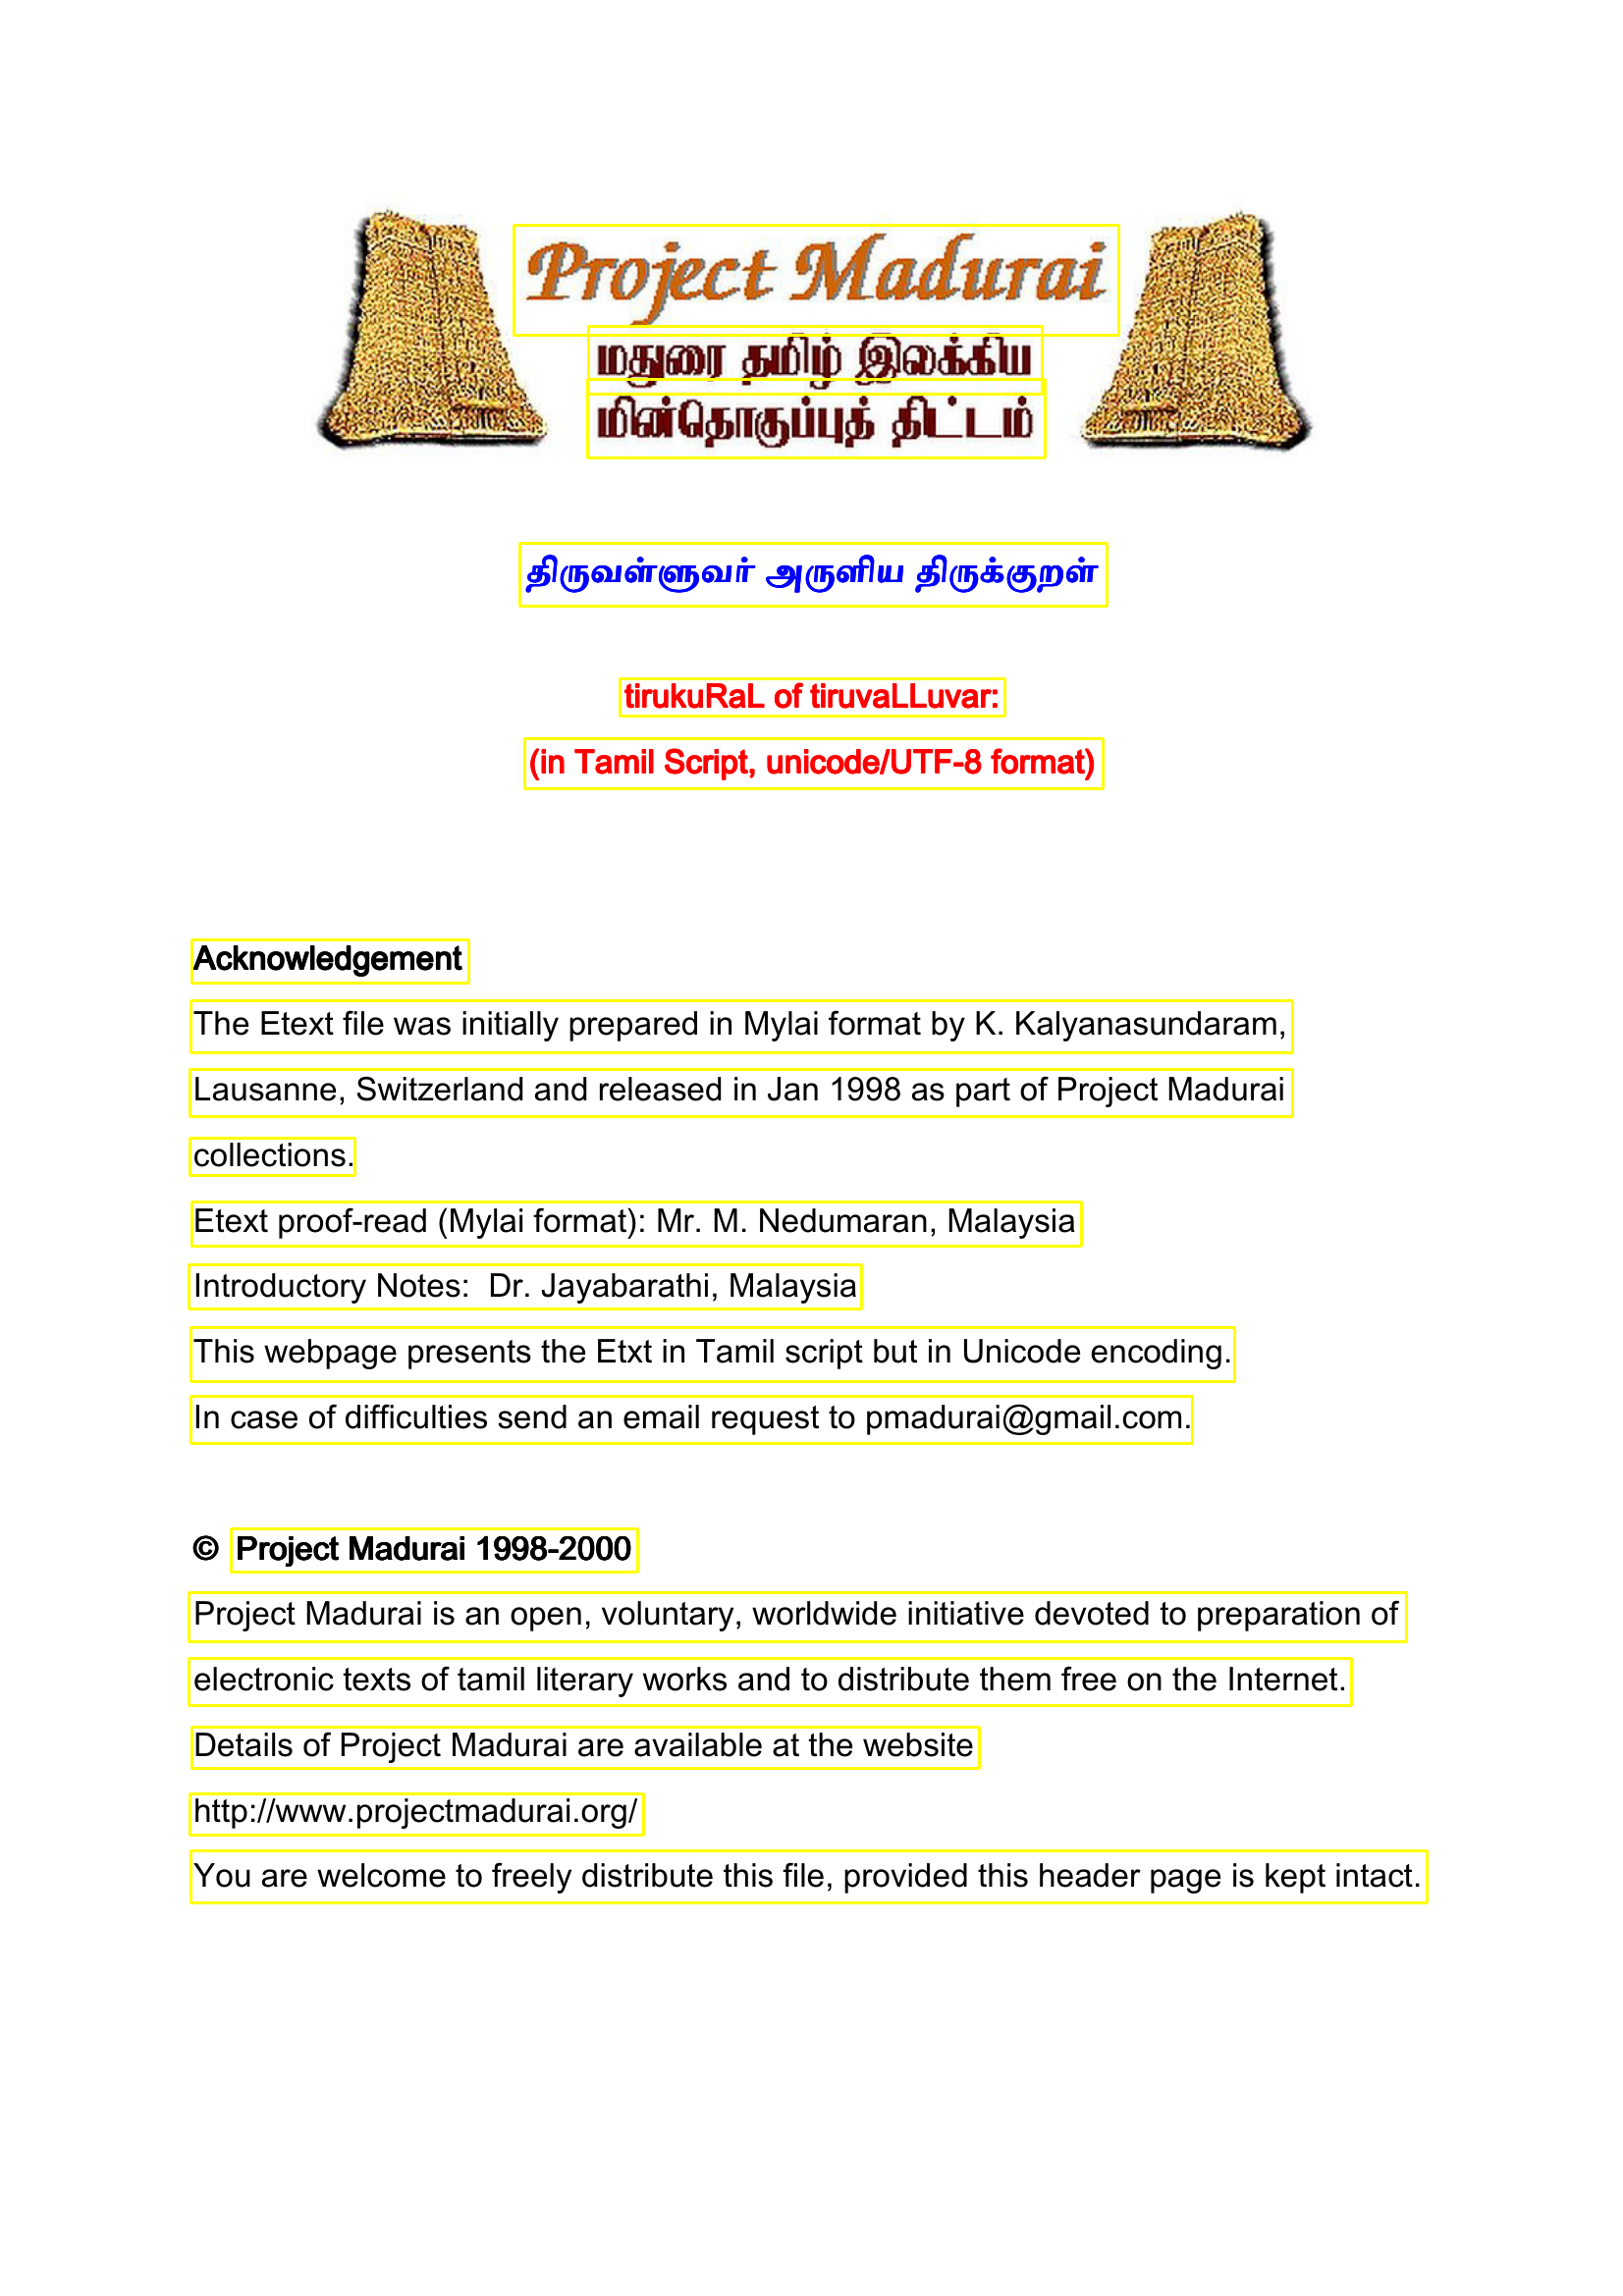

In [31]:
def draw_boxes(image, bounds, color='yellow', width=3):
  draw =ImageDraw.Draw(image)
  for bound in bounds: 
    p0, p1, p2, p3 = bound[0]
    draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
  return image 

draw_boxes(images[0], bounds)


In [32]:
bounds[0][1]

'0]%* )எ$யஅ@:'

In [33]:
text = ''

for i in range(len(bounds)):
  text=text+bounds[i][1] +'\n'

print(text)

0]%* )எ$யஅ@:
மதுரை தமிழ் இலக்கிய
மின்தொகுப்புத் திட்டம்
திருவள்ளுவர் அருளிய திருக்குறள்
3/ப&ய^4ட 06 (:/பௌ3ஔ!யௌ=:
(3" 7ஜஸ $7/), பாஞ0]/ஞஞ= 8 $0ஸ8()
^எ/0ய}]9}ஸ}"
} =<ீ< 1ீ ண3$ 3ற) )/}றஎ}] 3" 1ஹ= $0/ஸ8( லவ <. <4வ3ா=பொ]43ஸ,
_வப!ா"} $ய<%}ா] 35] /}}=}] 3" 33" 1998 8$ )எ 06 ?/+]}%* வ$ப[3
ண}ந(305
=<}< ,/+%6 [}=] ண= $0ஸ8): 1[ 1. வ}பஸ83" எஹ=$8
3ொ/+]ப<ணொ வ01}$: இ 4வ3லஎஎ(, எ=வ!=
^$ ய}+ஓ=9} )/}!}ொ$ (^} =(<( :" 7^ஸ $7/3)* +ப( 3" பாந0%} அ"ட04^9
3ொ <3!} 06 வ$ப} $}"] வ" அஸ= /பப} 10 ,ஸ=$ப=@!ற=ணணஸ
?0]} வ$ப[8 1998-2000
?0]}%( 14%ப[3 1$ வ" 0ற}/, %ணயொஎவ ண+3ய%} 3^*=(ள} %}ள01}] 10 )/}றஎ305 06
அ}%(/0"2 [}< 05 1வஸ <}வவ +&! வ"] 10 வ!/.ப} (^}ஸ ர/}} 0" <^} 3ொ}"}(
)}எ$ 06 ஹ+]ந 1$ப[ எ[} =ௌ3=ல} எ( <^} ண}!3}
5(றளயய )+} ஸ=$ொ=09
0ப 8[} ண}ணணஸ} 10 1/}வவ வ$(3.ப1} <^ 11|}, )+ௌ]}] <^$ }3%} )39} 1$ &}ற 3றஎ%(



##How to do Named Entity Recognization?

### Spacy Library 

In [34]:
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)

In [35]:
from spacy import displacy 

displacy.render(nlp(doc.text), style='ent', jupyter=True)